# Data Collection

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn  as sns

In [46]:
from google.colab import drive
drive.mount("/content/drive")
dataset = pd.read_csv('/content/drive/My Drive/Datasets/loan.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Preprocessing

In [47]:
# first 5 rows of the dataset
dataset.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


In [48]:
# check null values
print(dataset.isnull().sum())

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64


In [49]:
# check duplicate rows
duplicate_rows = dataset[dataset.duplicated()]
print("Duplicate Rows:")
duplicate_rows

Duplicate Rows:


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status


In [50]:
# unique value in target column
dataset['loan_status'].unique()

array([1, 0])

In [51]:
# dataset information
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  int64  
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  int64  
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  int64  
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  int64  
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [52]:
# number of rows and column
dataset.shape

(45000, 14)

In [53]:
# count the values in the 'loan_status' column
loan_status_counts = dataset['loan_status'].value_counts()
loan_status_counts

,count
loan_status,
0,35000
1,10000


# Feature Engineering

In [54]:
X = dataset.drop(['loan_status'],axis=1) # feature
y = dataset['loan_status'] # label

In [55]:
# convert to numerical: feature
X = pd.get_dummies(X)
X.head()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,person_gender_female,person_gender_male,...,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_No,previous_loan_defaults_on_file_Yes
0,22,71948,0,35000,16.02,0.49,3,561,True,False,...,False,True,False,False,False,False,True,False,True,False
1,21,12282,0,1000,11.14,0.08,2,504,True,False,...,True,False,False,True,False,False,False,False,False,True
2,25,12438,3,5500,12.87,0.44,3,635,True,False,...,False,False,False,False,False,True,False,False,True,False
3,23,79753,0,35000,15.23,0.44,2,675,True,False,...,False,True,False,False,False,True,False,False,True,False
4,24,66135,1,35000,14.27,0.53,4,586,False,True,...,False,True,False,False,False,True,False,False,True,False


In [56]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 27 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   person_age                          45000 non-null  int64  
 1   person_income                       45000 non-null  int64  
 2   person_emp_exp                      45000 non-null  int64  
 3   loan_amnt                           45000 non-null  int64  
 4   loan_int_rate                       45000 non-null  float64
 5   loan_percent_income                 45000 non-null  float64
 6   cb_person_cred_hist_length          45000 non-null  int64  
 7   credit_score                        45000 non-null  int64  
 8   person_gender_female                45000 non-null  bool   
 9   person_gender_male                  45000 non-null  bool   
 10  person_education_Associate          45000 non-null  bool   
 11  person_education_Bachelor           45000

In [57]:
# rebalance data
from imblearn.over_sampling import SMOTE

# apply SMOTE to oversample the minority class
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# print the class distribution after oversampling
print(pd.Series(y_resampled).value_counts())

loan_status
1    35000
0    35000
Name: count, dtype: int64


# Model Development

In [58]:
# train & test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled,
                                                    test_size=0.3, random_state=1) # test 30% train 70%

In [59]:
X_train.shape , X_test.shape

((49000, 27), (21000, 27))

In [60]:
y_train.shape , y_test.shape

((49000,), (21000,))

# Logistic Regression Model

Accuracy of Logistic Regression model: 0.9036190476190477

              precision    recall  f1-score   support

           0       0.95      0.86      0.90     10592
           1       0.87      0.95      0.91     10408

    accuracy                           0.90     21000
   macro avg       0.91      0.90      0.90     21000
weighted avg       0.91      0.90      0.90     21000

[[9095 1497]
 [ 527 9881]]


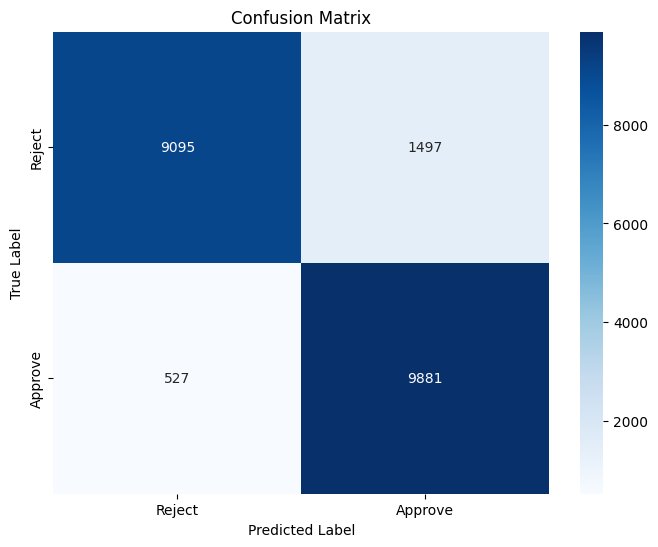

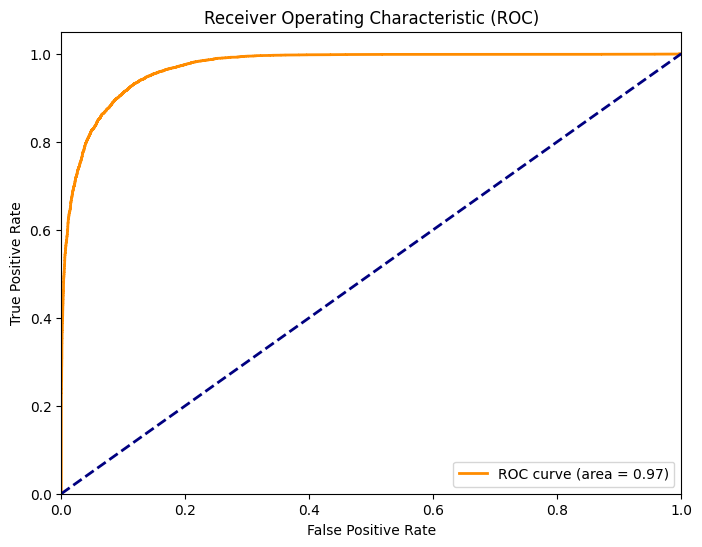

In [61]:
from sklearn.linear_model import LogisticRegression

# initialize and train the Logistic Regression model
log_reg = LogisticRegression(solver='liblinear')  # specify a solver
log_reg.fit(X_train, y_train)

# make predictions on the test set
y_pred = log_reg.predict(X_test)

# accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of Logistic Regression model: {accuracy}\n")

# report
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Reject', 'Approve'],
            yticklabels=['Reject', 'Approve'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ROC curve
y_prob = log_reg.predict_proba(X_test)[:, 1] # probabilities for the positive class
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# Naive Bayes Model

Accuracy of Naive Bayes model: 0.6421428571428571

              precision    recall  f1-score   support

           0       0.80      0.38      0.52     10592
           1       0.59      0.91      0.71     10408

    accuracy                           0.64     21000
   macro avg       0.70      0.64      0.62     21000
weighted avg       0.70      0.64      0.62     21000



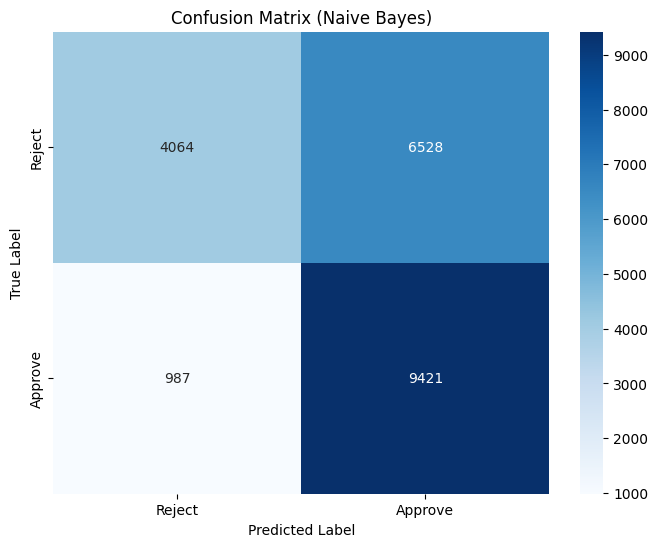

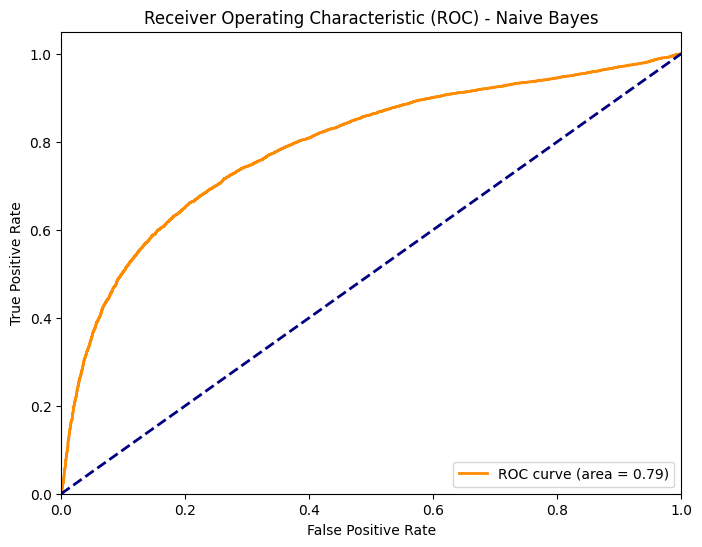

In [62]:
from sklearn.naive_bayes import GaussianNB

# initialize and train the Naive Bayes model
nb_classifier = GaussianNB()
nb_classifier.fit(X_train, y_train)

# make predictions on the test set
y_pred_nb = nb_classifier.predict(X_test)

# accuracy
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Accuracy of Naive Bayes model: {accuracy_nb}\n")
print(classification_report(y_test, y_pred_nb))

# confusion matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Reject', 'Approve'],
            yticklabels=['Reject', 'Approve'])
plt.title('Confusion Matrix (Naive Bayes)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ROC curve
y_prob_nb = nb_classifier.predict_proba(X_test)[:, 1]
fpr_nb, tpr_nb, thresholds_nb = roc_curve(y_test, y_prob_nb)
roc_auc_nb = auc(fpr_nb, tpr_nb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_nb, tpr_nb, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_nb)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Naive Bayes')
plt.legend(loc="lower right")
plt.show()

# Random Forest Model

Accuracy of Random Forest model: 0.9546190476190476

              precision    recall  f1-score   support

           0       0.95      0.96      0.96     10592
           1       0.96      0.95      0.95     10408

    accuracy                           0.95     21000
   macro avg       0.95      0.95      0.95     21000
weighted avg       0.95      0.95      0.95     21000



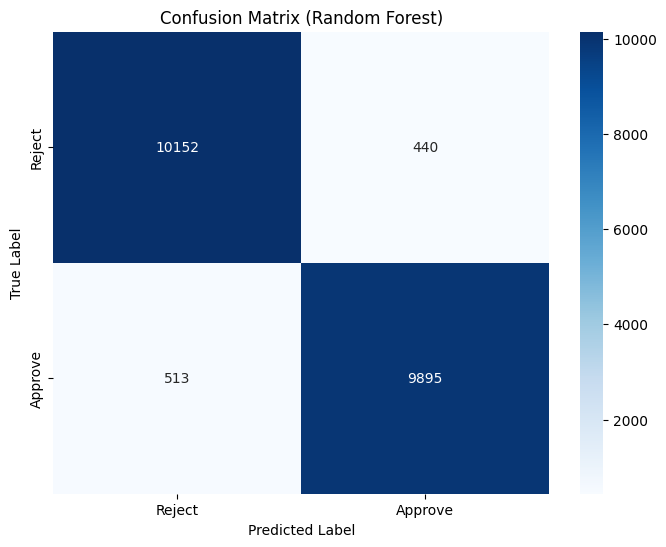

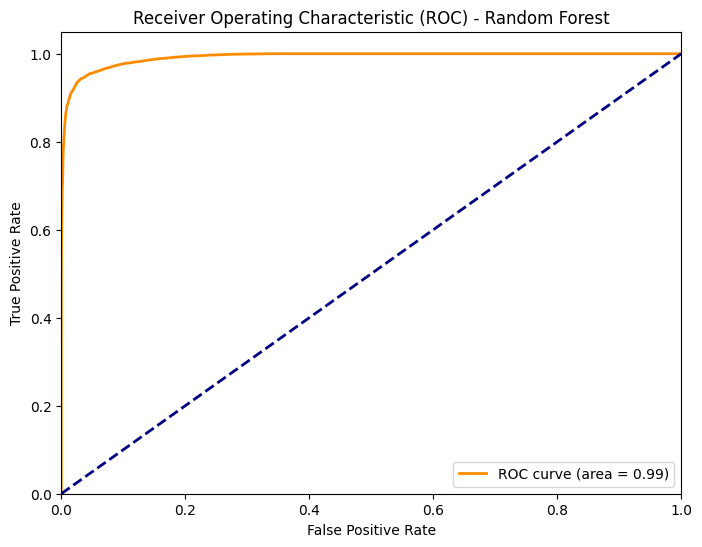

In [63]:
from sklearn.ensemble import RandomForestClassifier

# initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42) # can adjust n_estimators
rf_classifier.fit(X_train, y_train)

# make predictions
y_pred_rf = rf_classifier.predict(X_test)

# accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy of Random Forest model: {accuracy_rf}\n")
print(classification_report(y_test, y_pred_rf))

# confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Reject', 'Approve'],
            yticklabels=['Reject', 'Approve'])
plt.title('Confusion Matrix (Random Forest)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ROC curve
y_prob_rf = rf_classifier.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_rf)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Random Forest')
plt.legend(loc="lower right")
plt.show()